# Predicting Heart Disease

The following notebook contains my attempt at the Predicting Heart Disease competition: https://www.kaggle.com/competitions/playground-series-s6e2/overview.

### Data Dictionary

| Variable | Definition | Key |
| :--- | :--- | :--- |
| **id** | Unique patient identifier | |
| **Age** | Age of the patient | Years (29 - 77) |
| **Sex** | Biological sex | 0: female, 1: male |
| **Chest pain type** | Type of chest pain reported | 1: typical, 2: atypical, 3: non-anginal, 4: asymptomatic |
| **BP** | Resting blood pressure | Continuous (mm Hg) |
| **Cholesterol** | Serum cholesterol level | Continuous (mg/dl) |
| **FBS over 120** | Fasting blood sugar > 120 mg/dl | 0: false, 1: true |
| **EKG results** | Resting electrocardiographic results | 0: normal, 1: ST-T abnormal, 2: LV hypertrophy |
| **Max HR** | Maximum heart rate achieved | Continuous (bpm) |
| **Exercise angina** | Exercise-induced chest pain | 0: no, 1: yes |
| **ST depression** | ST depression induced by exercise | Continuous (Oldpeak) |
| **Slope of ST** | Slope of peak exercise ST segment | 1: upsloping, 2: flat, 3: downsloping |
| **Number of vessels fluro** | Number of major vessels colored by fluro | 0 - 3 |
| **Thallium** | Thallium stress test result | 3: normal, 6: fixed defect, 7: reversible defect |
| **Heart Disease** | **Target:** Presence of cardiac pathology | Absence, Presence |

In [1]:
!pip install shap

In [2]:
import sys
print(sys.executable)

C:\Users\kiera\AppData\Local\Programs\Python\Python313\python.exe


In [107]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, RepeatedKFold
import numpy as np
import shap
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier

In [4]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

In [5]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

In [6]:
train_df.isnull().any()

id                         False
Age                        False
Sex                        False
Chest pain type            False
BP                         False
Cholesterol                False
FBS over 120               False
EKG results                False
Max HR                     False
Exercise angina            False
ST depression              False
Slope of ST                False
Number of vessels fluro    False
Thallium                   False
Heart Disease              False
dtype: bool

In [7]:
train_df.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


In [8]:
train_df.describe()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,54.136706,0.714735,3.312752,130.497433,245.011814,0.079987,0.981660,152.816763,0.273725,0.716028,1.455871,0.451040,4.618873
std,181865.479132,8.256301,0.451541,0.851615,14.975802,33.681581,0.271274,0.998783,19.112927,0.445870,0.948472,0.545192,0.798549,1.950007
min,0.000000,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000
25%,157499.750000,48.000000,0.000000,3.000000,120.000000,223.000000,0.000000,0.000000,142.000000,0.000000,0.000000,1.000000,0.000000,3.000000
50%,314999.500000,54.000000,1.000000,4.000000,130.000000,243.000000,0.000000,0.000000,157.000000,0.000000,0.100000,1.000000,0.000000,3.000000
75%,472499.250000,60.000000,1.000000,4.000000,140.000000,269.000000,0.000000,2.000000,166.000000,1.000000,1.400000,2.000000,1.000000,7.000000
max,629999.000000,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000


In [9]:
train_df.columns

Index(['id', 'Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol',
       'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina',
       'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium',
       'Heart Disease'],
      dtype='object')

In [10]:
train_df.dtypes

id                           int64
Age                          int64
Sex                          int64
Chest pain type              int64
BP                           int64
Cholesterol                  int64
FBS over 120                 int64
EKG results                  int64
Max HR                       int64
Exercise angina              int64
ST depression              float64
Slope of ST                  int64
Number of vessels fluro      int64
Thallium                     int64
Heart Disease               object
dtype: object

In [11]:
target_map = {
    "Presence": 1,
    "Absence": 0
}

train_df["Heart Disease"] = train_df["Heart Disease"].map(target_map)

# Feature Engineering

# HR

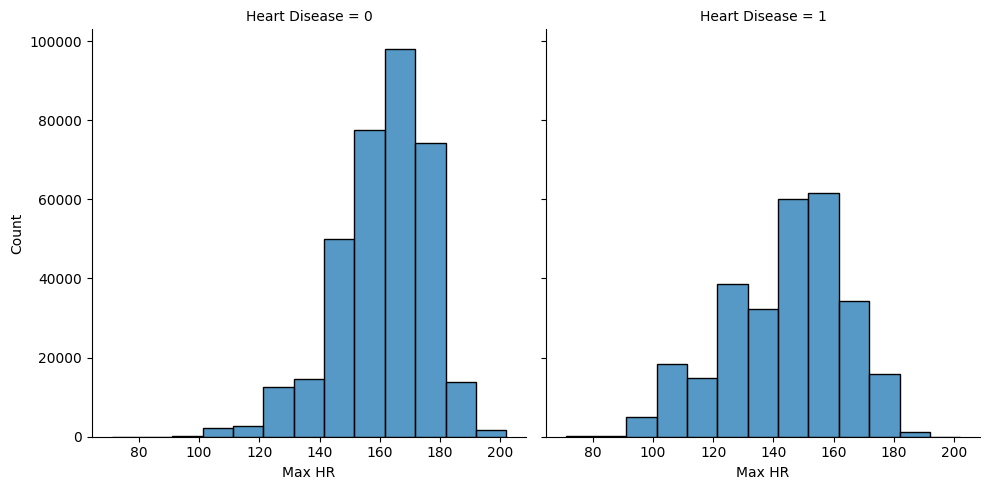

In [12]:
sns.displot(train_df, x='Max HR', col='Heart Disease', binwidth=10, height=5)
plt.show()

In [13]:
train_df['HR_cut'] = pd.qcut(train_df['Max HR'], 8)
test_df['HR_cut'] = pd.qcut(test_df['Max HR'], 8)


train_df.groupby(["HR_cut"], as_index=False, observed=True)['Heart Disease'].mean()

,HR_cut,Heart Disease
0,"(70.999, 126.0]",0.835963
1,"(126.0, 142.0]",0.669809
2,"(142.0, 150.0]",0.566864
3,"(150.0, 157.0]",0.438843
4,"(157.0, 162.0]",0.370023
5,"(162.0, 166.0]",0.249131
6,"(166.0, 173.0]",0.230840
7,"(173.0, 202.0]",0.134491


In [14]:
# encode HR
bins = [70.999, 126, 142, 150, 157, 162, 166, 173, 202]
labels = [0, 1, 2, 3, 4, 5, 6, 7]

train_df['HR_group'] = pd.cut(train_df['Max HR'], bins=bins, labels=labels, right=True)
test_df['HR_group']  = pd.cut(test_df['Max HR'], bins=bins, labels=labels, right=True)

# Cholesterol

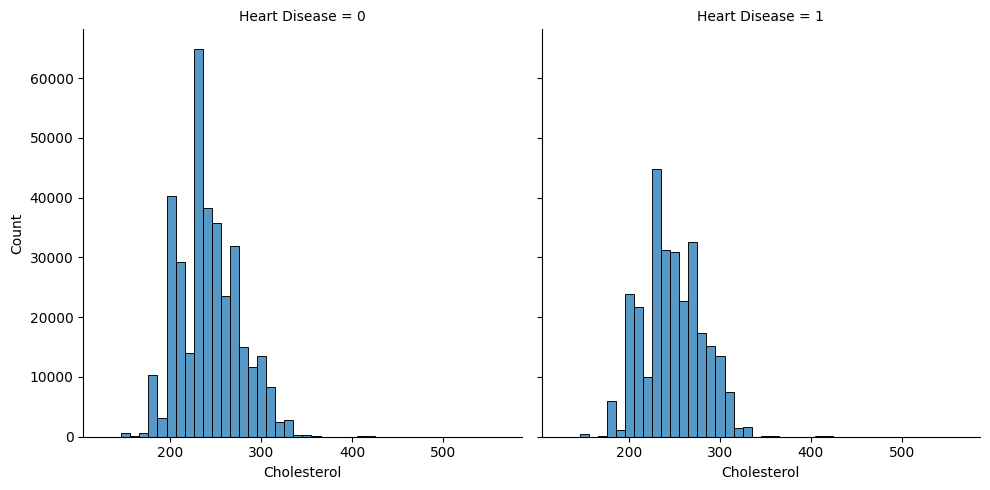

In [15]:
sns.displot(train_df, x='Cholesterol', col='Heart Disease', binwidth=10, height=5)
plt.show()

In [16]:
train_df['cholesterol_cut'] = pd.qcut(train_df['Cholesterol'], 8)
test_df['cholesterol_cut'] = pd.qcut(test_df['Cholesterol'], 8)


train_df.groupby(["cholesterol_cut"], as_index=False, observed=True)['Heart Disease'].mean()

,cholesterol_cut,Heart Disease
0,"(125.999, 204.0]",0.363335
1,"(204.0, 223.0]",0.423714
2,"(223.0, 233.0]",0.411033
3,"(233.0, 243.0]",0.428045
4,"(243.0, 254.0]",0.466487
5,"(254.0, 269.0]",0.495575
6,"(269.0, 286.0]",0.521062
7,"(286.0, 564.0]",0.493541


In [17]:
# encode Cholesterol
bins = [125, 204, 223, 233, 243, 254, 269, 286, 564]
labels = [0, 1, 2, 3, 4, 5, 6, 7]

train_df['cholesterol_group'] = pd.cut(train_df['Cholesterol'], bins=bins, labels=labels, right=True)
test_df['cholesterol_group']  = pd.cut(test_df['Cholesterol'], bins=bins, labels=labels, right=True)

In [18]:
train_df

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease,HR_cut,HR_group,cholesterol_cut,cholesterol_group
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,1,"(157.0, 162.0]",4,"(233.0, 243.0]",3
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,0,"(166.0, 173.0]",6,"(286.0, 564.0]",7
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,0,"(150.0, 157.0]",3,"(125.999, 204.0]",0
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,0,"(142.0, 150.0]",2,"(223.0, 233.0]",2
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,1,"(70.999, 126.0]",0,"(233.0, 243.0]",3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
629995,629995,56,0,1,110,226,0,0,132,0,0.0,1,0,7,0,"(126.0, 142.0]",1,"(223.0, 233.0]",2
629996,629996,54,1,4,128,249,1,2,150,0,0.0,2,0,3,0,"(142.0, 150.0]",2,"(243.0, 254.0]",4
629997,629997,67,1,4,130,275,0,0,149,0,0.0,1,2,7,1,"(142.0, 150.0]",2,"(269.0, 286.0]",6
629998,629998,52,1,4,140,199,0,2,157,0,0.0,1,0,6,1,"(150.0, 157.0]",3,"(125.999, 204.0]",0


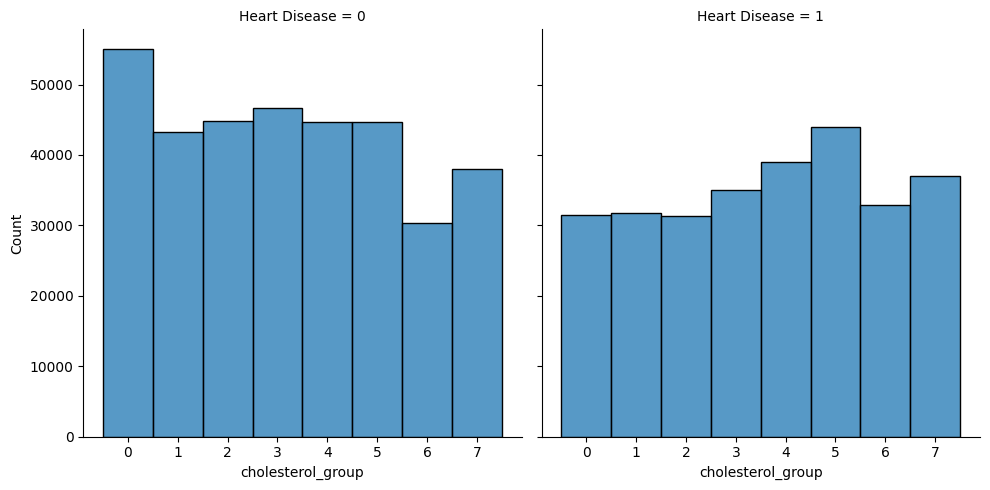

In [19]:
sns.displot(train_df, x='cholesterol_group', col='Heart Disease', height=5)
plt.show()

In [20]:
target = 'Heart Disease'

corr_matrix = train_df.corr(numeric_only=True)

target_corr = corr_matrix[[target]].sort_values(by=target, ascending=False)

print(f"Features correlated with {target}:")
display(target_corr)

Features correlated with Heart Disease:


,Heart Disease
Heart Disease,1.000000
Thallium,0.605776
Chest pain type,0.460684
Exercise angina,0.441864
Number of vessels fluro,0.438604
ST depression,0.430641
Slope of ST,0.415050
Sex,0.342446
EKG results,0.218961
Age,0.212091


In [21]:
strong_corr = target_corr[target_corr["Heart Disease"].abs() > 0.4]
display(strong_corr)

,Heart Disease
Heart Disease,1.000000
Thallium,0.605776
Chest pain type,0.460684
Exercise angina,0.441864
Number of vessels fluro,0.438604
ST depression,0.430641
Slope of ST,0.415050
Max HR,-0.440985


In [146]:
X = train_df[[
    "Thallium",
    "Chest pain type",
    "Exercise angina",
    "Number of vessels fluro",
    "ST depression",
    "Slope of ST",
    "Max HR"
]]

y = train_df["Heart Disease"]

model = LinearRegression()
model.fit(X, y)

print(f"Intercept: {model.intercept_:.4f}")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef:.4f}")

Intercept: 0.1419
Thallium: 0.0816
Chest pain type: 0.1145
Exercise angina: 0.1537
Number of vessels fluro: 0.0897
ST depression: 0.0560
Slope of ST: 0.1086
Max HR: -0.0048


In [147]:
model.coef_

array([ 0.08156168,  0.11452014,  0.15369855,  0.089741  ,  0.05600351,
        0.10856774, -0.00477952])

In [148]:
coefs = model.coef_
intercept = model.intercept_ 

train_df["reg_feature"] = train_df["Thallium"] * coefs[0] + \
train_df["Chest pain type"] * coefs[1] + \
train_df["Exercise angina"] * coefs[2] + \
train_df["Number of vessels fluro"] * coefs[3] + \
train_df["ST depression"] * coefs[4] + \
train_df["Slope of ST"] * coefs[5] + \
train_df["Max HR"] * coefs[6] + \
intercept

test_df["reg_feature"] = test_df["Thallium"] * coefs[0] + \
                         test_df["Chest pain type"] * coefs[1] + \
                         test_df["Exercise angina"] * coefs[2] + \
                         test_df["Number of vessels fluro"] * coefs[3] + \
                         test_df["ST depression"] * coefs[4] + \
                         test_df["Slope of ST"] * coefs[5] + \
                         test_df["Max HR"] * coefs[6] + \
                         intercept

In [26]:
def create_regression_feature(features_list, new_feature_name):
    X = train_df[features_list]
    y = train_df["Heart Disease"]

    model = LinearRegression()
    model.fit(X, y)

    coefs = model.coef_
    intercept = model.intercept_ 

    train_df[new_feature_name] = train_df[features_list].dot(coefs) + intercept

    print(f"Intercept: {model.intercept_:.4f}")
    for feature, coef in zip(X.columns, model.coef_):
        print(f"{feature}: {coef:.4f}")

    return f"{new_feature_name} has been added"

In [27]:
train_df.drop(["HR_cut", "cholesterol_cut"], axis=1)

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease,HR_group,cholesterol_group,reg_feature
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,1,4,3,1.167699
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,0,6,7,-0.207603
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,0,3,0,0.002507
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,0,2,2,0.286378
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,1,0,3,1.100118
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
629995,629995,56,0,1,110,226,0,0,132,0,0.0,1,0,7,0,1,2,0.305045
629996,629996,54,1,4,128,249,1,2,150,0,0.0,2,0,3,0,2,4,0.344895
629997,629997,67,1,4,130,275,0,0,149,0,0.0,1,2,7,1,2,6,0.746835
629998,629998,52,1,4,140,199,0,2,157,0,0.0,1,0,6,1,3,0,0.447556


In [28]:
# need to do target encoding with these variables:

  # "Thallium",
  #   "Chest pain type",
  #   "Exercise angina",
  #   "Number of vessels fluro",
  #   "ST depression",
  #   "Slope of ST",
  #   "Max HR"

In [29]:
# train_df = train_df.drop("Heart Disease_sq", axis=1)

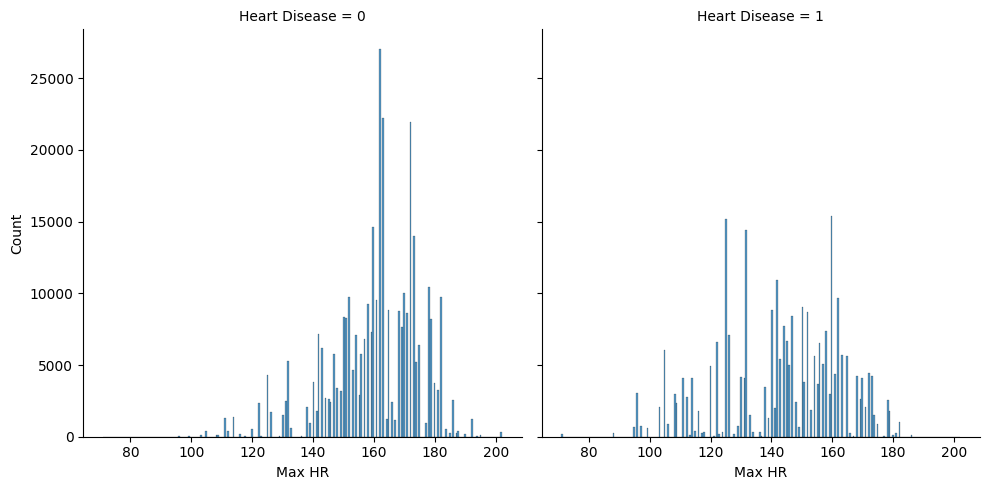

In [30]:
sns.displot(train_df, x='Max HR', col='Heart Disease', height=5)
plt.show()

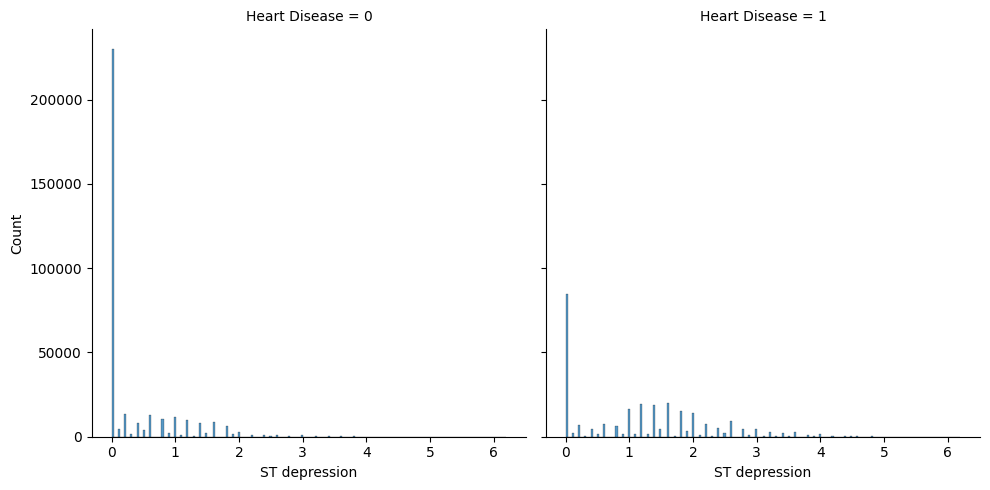

In [31]:
sns.displot(train_df, x='ST depression', col='Heart Disease', height=5)
plt.show()

In [32]:
train_df.groupby("Chest pain type")["Heart Disease"].count()

Chest pain type
1     28602
2     74941
3    197278
4    329179
Name: Heart Disease, dtype: int64

In [33]:
train_df["Number of vessels fluro"].value_counts()

Number of vessels fluro
0    445862
1    106978
2     54303
3     22857
Name: count, dtype: int64

In [34]:
cols = ["Thallium",
    "Chest pain type",
    "Exercise angina",
    "Number of vessels fluro",
    "ST depression",
    "Slope of ST",
    "Max HR"]

for col in cols:
    print(train_df[col].value_counts())

Thallium
3    372286
7    246748
6     10966
Name: count, dtype: int64
Chest pain type
4    329179
3    197278
2     74941
1     28602
Name: count, dtype: int64
Exercise angina
0    457553
1    172447
Name: count, dtype: int64
Number of vessels fluro
0    445862
1    106978
2     54303
3     22857
Name: count, dtype: int64
ST depression
0.00    314939
1.20     29269
1.00     28647
1.60     28395
1.40     27146
         ...  
4.70         4
5.10         2
2.12         1
5.90         1
0.06         1
Name: count, Length: 66, dtype: int64
Slope of ST
1    358293
2    256215
3     15492
Name: count, dtype: int64
Max HR
162    36703
160    30000
163    27914
172    26376
132    19643
       ...  
137       38
127       20
110        8
94         2
201        1
Name: count, Length: 93, dtype: int64


In [35]:
bins = [-float('inf'), 0, 1, 2, 3, float('inf')]
labels = [0, 1, 2, 3, 4]

train_df['ST_depression_group'] = pd.cut(train_df["ST depression"], bins=bins, labels=labels)
test_df['ST_depression_group'] = pd.cut(test_df["ST depression"], bins=bins, labels=labels)

# Feature target encoding

In [36]:
cols_to_encode = ["Thallium", 
                  "Chest pain type", 
                  "Exercise angina", 
                  "Number of vessels fluro",
                  "Slope of ST",
                  "HR_group",
                  "ST_depression_group"]

In [37]:
def train_target_encoding(cols_to_encode):
    results = []
    
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    
    for col in cols_to_encode:
        train_df[f"tar_{col}"] = np.nan
    
    for train_idx, val_idx in kf.split(train_df):
        df_train_split = train_df.iloc[train_idx].copy()
        df_val_split = train_df.iloc[val_idx].copy()
        
        for col in cols_to_encode:
            mean = df_train_split.groupby(col)["Heart Disease"].mean()
            
            df_val_split[f"tar_{col}"] = df_val_split[col].map(mean).astype(float)
            
        results.append(df_val_split)
    
    encoded_df = pd.concat(results).sort_index()

    return encoded_df

In [38]:
def test_target_encoding(df, cols_to_encode):
    
    results = []
      
    for col in cols_to_encode:
        df[f"tar_{col}"] = np.nan
        mean = train_df.groupby(col)["Heart Disease"].mean()
        df[f"tar_{col}"] = df[col].map(mean).astype(float)
        
    results.append(df)
    encoded_df = pd.concat(results).sort_index()

    return encoded_df

In [39]:
df = test_target_encoding(test_df, cols_to_encode)
df["tar_Thallium"].value_counts()

tar_Thallium
0.198049    159498
0.815391    105833
0.686394      4669
Name: count, dtype: int64

In [40]:
train_df = train_target_encoding(cols_to_encode)
train_df["tar_Thallium"].value_counts()

tar_Thallium
0.197738    74817
0.197903    74499
0.198145    74429
0.198719    74297
0.197741    74244
0.815058    49524
0.815563    49499
0.815777    49395
0.815372    49340
0.815183    48990
0.683536     2232
0.684717     2231
0.687058     2204
0.689388     2193
0.687246     2106
Name: count, dtype: int64

In [41]:
target = 'Heart Disease'

corr_matrix = train_df.corr(numeric_only=True)

target_corr = corr_matrix[[target]].sort_values(by=target, ascending=False)

print(f"Features correlated with {target}:")
display(target_corr)

Features correlated with Heart Disease:


,Heart Disease
Heart Disease,1.000000
reg_feature,0.764562
tar_Thallium,0.605807
Thallium,0.605776
tar_Chest pain type,0.525184
tar_Number of vessels fluro,0.463223
Chest pain type,0.460684
Exercise angina,0.441864
tar_Exercise angina,0.441859
tar_HR_group,0.440710


In [45]:
train_df["tar_Thallium"].isnull().any()

np.False_

In [62]:
try:
    train_df.drop("id", axis=1, inplace=True)
    train_df.drop("HR_cut", axis=1, inplace=True)
    train_df.drop("cholesterol_cut", axis=1, inplace=True)
except KeyError:
    print("Columns have been removed already")

Columns have been removed already


In [111]:
original_df = train_df.iloc[:, :14]

In [112]:
target = "Heart Disease"
X = original_df.drop(target, axis=1)
y = original_df[target]

In [113]:
original_df

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,1
1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,0
2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,0
3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,0
4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
629995,56,0,1,110,226,0,0,132,0,0.0,1,0,7,0
629996,54,1,4,128,249,1,2,150,0,0.0,2,0,3,0
629997,67,1,4,130,275,0,0,149,0,0.0,1,2,7,1
629998,52,1,4,140,199,0,2,157,0,0.0,1,0,6,1


In [114]:
cat_cols = ["Sex", 
            "Chest pain type",
            "FBS over 120",
            "EKG results",
            "Exercise angina",
            "Slope of ST",
            "Thallium"]

original_encoded = pd.get_dummies(original_df, columns=cat_cols, drop_first=True).astype(int)

In [115]:
original_encoded

,Age,BP,Cholesterol,Max HR,ST depression,Number of vessels fluro,Heart Disease,Sex_1,Chest pain type_2,Chest pain type_3,Chest pain type_4,FBS over 120_1,EKG results_1,EKG results_2,Exercise angina_1,Slope of ST_2,Slope of ST_3,Thallium_6,Thallium_7
0,58,152,239,158,3,2,1,1,0,0,1,0,0,0,1,1,0,0,1
1,52,125,325,171,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0
2,56,160,188,151,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0
3,44,134,229,150,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0
4,58,140,234,125,3,3,1,1,0,0,1,0,0,1,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
629995,56,110,226,132,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
629996,54,128,249,150,0,0,0,1,0,0,1,1,0,1,0,1,0,0,0
629997,67,130,275,149,0,2,1,1,0,0,1,0,0,0,0,0,0,0,1
629998,52,140,199,157,0,0,1,1,0,0,1,0,0,1,0,0,0,1,0


In [116]:
df_interactions = original_encoded.copy()
cols = [c for c in df_interactions.columns if c != 'Heart Disease']

interactions_dict = {}

for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        new_col_name = f"{cols[i]}_x_{cols[j]}"
        interactions_dict[new_col_name] = original_encoded[cols[i]] * original_encoded[cols[j]]

df_interactions = pd.DataFrame(interactions_dict)
df_final = pd.concat([original_encoded, df_interactions], axis=1)

X = df_final.drop('Heart Disease', axis=1)
y = df_final['Heart Disease']

model = RandomForestClassifier(n_estimators=100, random_state=1)
model.fit(X, y)

importance = pd.Series(model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False).head(15)

print(importance)

Max HR_x_Thallium_7                  0.060879
Sex_1_x_Thallium_7                   0.043415
Max HR_x_Chest pain type_4           0.038805
Thallium_7                           0.032001
BP_x_Thallium_7                      0.031486
Cholesterol_x_Thallium_7             0.031319
Age_x_Thallium_7                     0.028462
Cholesterol_x_Chest pain type_4      0.027849
Sex_1_x_Chest pain type_4            0.026166
BP_x_Chest pain type_4               0.025591
Age_x_Chest pain type_4              0.024534
Max HR                               0.024242
ST depression_x_Chest pain type_4    0.019795
Cholesterol_x_Max HR                 0.018827
BP_x_Max HR                          0.018717
dtype: float64


In [130]:
train_df["Thallium_7"] = np.where(train_df["Thallium"] == 7, 1, 0)
train_df["Chest_pain_type_4"] = np.where(train_df["Chest pain type"] == 4, 1, 0)
train_df["Male"] = np.where(train_df["Sex"] == 1, 1, 0)

train_df["Max HR_x_Thallium_7"] =               train_df["Max HR"] * train_df["Thallium_7"]
train_df["Male_x_Thallium_7"] =                 train_df["Male"] * train_df["Thallium_7"] 
train_df["Max HR_x_Chest pain type_4"] =        train_df["Max HR"] * train_df["Chest_pain_type_4"]
train_df["BP_x_Thallium_7"] =                   train_df["BP"] * train_df["Thallium_7"]
train_df["Cholesterol_x_Thallium_7"] =          train_df["Cholesterol"] * train_df["Thallium_7"]
train_df["Age_x_Thallium_7"] =                  train_df["Age"] * train_df["Thallium_7"]
train_df["Cholesterol_x_Chest pain type_4"] =   train_df["Cholesterol"] * train_df["Chest_pain_type_4"]
train_df["Male_x_Chest pain type_4"] =          train_df["Male"] * train_df["Chest_pain_type_4"]
train_df["BP_x_Chest pain type_4"] =            train_df["BP"] * train_df["Chest_pain_type_4"]
train_df["Age_x_Chest pain type_4"] =           train_df["Age"] * train_df["Chest_pain_type_4"]

In [132]:
test_df["Thallium_7"] = np.where(test_df["Thallium"] == 7, 1, 0)
test_df["Chest_pain_type_4"] = np.where(test_df["Chest pain type"] == 4, 1, 0)
test_df["Male"] = np.where(test_df["Sex"] == 1, 1, 0)

test_df["Max HR_x_Thallium_7"] =              test_df["Max HR"] * test_df["Thallium_7"]
test_df["Male_x_Thallium_7"] =                test_df["Male"] * test_df["Thallium_7"] 
test_df["Max HR_x_Chest pain type_4"] =       test_df["Max HR"] * test_df["Chest_pain_type_4"]
test_df["BP_x_Thallium_7"] =                  test_df["BP"] * test_df["Thallium_7"]
test_df["Cholesterol_x_Thallium_7"] =         test_df["Cholesterol"] * test_df["Thallium_7"]
test_df["Age_x_Thallium_7"] =                 test_df["Age"] * test_df["Thallium_7"]
test_df["Cholesterol_x_Chest pain type_4"] =  test_df["Cholesterol"] * test_df["Chest_pain_type_4"]
test_df["Male_x_Chest pain type_4"] =         test_df["Male"] * test_df["Chest_pain_type_4"]
test_df["BP_x_Chest pain type_4"] =           test_df["BP"] * test_df["Chest_pain_type_4"]
test_df["Age_x_Chest pain type_4"] =          test_df["Age"] * test_df["Chest_pain_type_4"]

In [141]:
X = train_df.drop('Heart Disease', axis=1)
y = train_df['Heart Disease']

model = RandomForestClassifier(n_estimators=100, 
                               random_state=1,
                              max_depth=15,
                              n_jobs=-1)
model.fit(X,y)


,n_estimators,100
,criterion,'gini'
,max_depth,15
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [142]:
accuracy = model.score(X, y)
print(f"Training Accuracy: {accuracy:.2%}")

Training Accuracy: 91.35%


In [149]:
""" 
next to improve, i need to go through each feature and extract more aggregations that improve feature engineering

also, i need to consider more agregations based on age, sex etc, and identify the individuals that are outliers in a particular category
"""

' \nnext to improve, i need to go through each feature and extract more aggregations that improve feature engineering\n\nalso, i need to consider more agregations based on age, sex etc, and identify the individuals that are outliers in a particular category\n'